<a href="https://colab.research.google.com/github/leotamasauskas/SARIMA-Model-Statistical-Air-Temperature-Forecasting-for-Bel-m-PA-/blob/main/SA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pmdarima
!pip install statsmodels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from google.colab import drive
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Caminho do arquivo no Google Drive
caminho_arquivo = '/content/drive/My Drive/Belem/BELEM_temperature_2m_1994-2024.csv'

# Carregar os dados
dados = pd.read_csv(caminho_arquivo)

# Certificar-se de que a coluna 'date' é datetime
dados['date'] = pd.to_datetime(dados['date'])

# Definir a coluna 'date' como índice
dados = dados.set_index('date')

# Verificar valores faltantes em 'temperature_2m'
print("Valores faltantes em temperature_2m:", dados['temperature_2m'].isnull().sum())

# Remover linhas com valores faltantes em 'temperature_2m'
dados = dados.dropna(subset=['temperature_2m'])

# Converter temperatura de Kelvin para Celsius
dados['temperature_2m'] = dados['temperature_2m'] - 273.15

# Exibir estatísticas descritivas
print(dados['temperature_2m'].describe())

# Exibir as primeiras linhas para conferência
print(dados.head())


Valores faltantes em temperature_2m: 0
count    11323.000000
mean        26.589949
std          1.071000
min         23.536224
25%         25.765164
50%         26.580064
75%         27.448345
max         29.529403
Name: temperature_2m, dtype: float64
            temperature_2m
date                      
1994-01-01       25.691116
1994-01-02       25.715554
1994-01-03       25.030084
1994-01-04       24.495098
1994-01-05       25.437193


In [ ]:
# Teste de Dickey-Fuller Aumentado (ADF)
def adf_test(timeseries):
    print('Resultados do Teste de Dickey-Fuller Aumentado:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [ ]:
# Aplicar o teste ADF na coluna 'temperature_2m'
adf_test(dados['temperature_2m'])

Resultados do Teste de Dickey-Fuller Aumentado:
Test Statistic                -7.489156e+00
p-value                        4.554005e-11
#Lags Used                     1.600000e+01
Number of Observations Used    1.130600e+04
Critical Value (1%)           -3.430929e+00
Critical Value (5%)           -2.861796e+00
Critical Value (10%)          -2.566906e+00
dtype: float64


In [ ]:
# Usando auto_arima para encontrar os melhores parâmetros
auto_model = auto_arima(dados['temperature_2m'], seasonal=True, m=7, stepwise=True, trace=True, suppress_warnings=True)
print(auto_model.summary())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=12149.044, Time=64.70 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=13687.837, Time=2.18 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,1,3)(0,0,0)[7]             : AIC=12184.722, Time=2.31 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(0,0,0)[7]             : AIC=12156.181, Time=2.30 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,3)(0,0,0)[7]             : AIC=12144.023, Time=8.52 sec

Best model:  ARIMA(1,1,2)(0,0,0)[7]          
Total fit time: 508.296 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                11323
Model:               SARIMAX(1, 1, 2)   Log Likelihood               -6066.582
Date:                Mon, 31 Mar 2025   AIC                          12141.164
Time:                        14:20:17   BIC                          12170.502
Sample:                    01-01-1994   HQIC                         12151.034
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4069      0.019     21.836      0.000       0.3

In [ ]:
# Definindo parâmetros SARIMA (p, d, q, P, D, Q, s) com base no auto_arima
p, d, q = auto_model.order
P, D, Q, s = auto_model.seasonal_order


In [ ]:
# Definição do tamanho do passo
step_size = 8
train_size = int(len(dados) * 0.8)  # 80% dos dados para treino
test_size = len(dados) - train_size

In [ ]:
# Separando os conjuntos de treino e teste
train, test = dados['temperature_2m'][:train_size], dados['temperature_2m'][train_size:]

In [ ]:
# Lista para armazenar previsões
predictions = []

In [ ]:
# Loop de previsão iterativa
for i in range(0, test_size, step_size):
    model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, s), enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)

    # Prevê os próximos `step_size` passos
    forecast = model_fit.forecast(steps=step_size)

    # Armazena previsões
    predictions.extend(forecast)

    # Atualiza os dados de treinamento com os valores reais
    train = pd.concat([train, test[i:i+step_size]])

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [ ]:
# Criando DataFrame para comparação
pred_series = pd.Series(predictions[:len(test)], index=test.index)


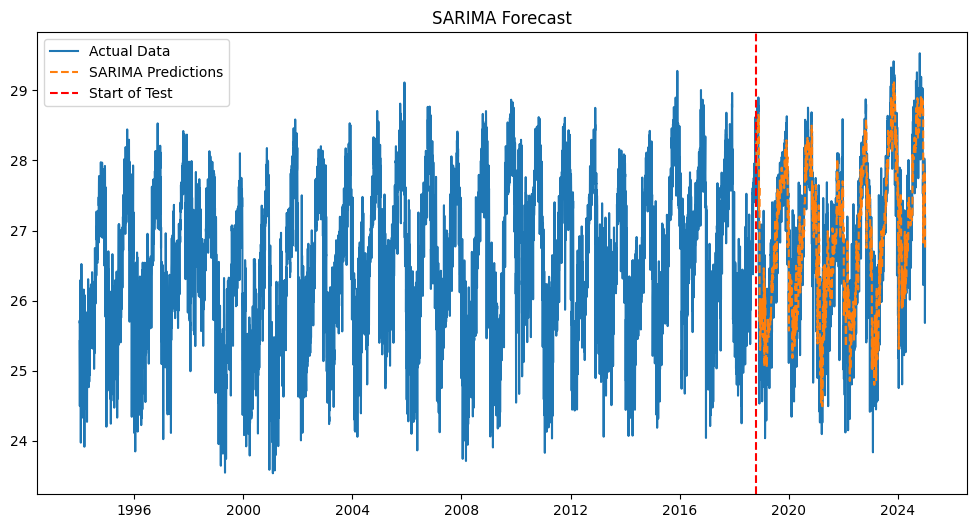

In [ ]:
# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(dados['temperature_2m'], label='Actual Data')
plt.plot(pred_series, label='SARIMA Predictions', linestyle='dashed')
plt.axvline(x=test.index[0], color='red', linestyle='--', label='Start of Test')
plt.legend()
plt.title('SARIMA Forecast')
plt.show()


In [ ]:
# Calculando as métricas
mse = mean_squared_error(test, pred_series)
mae = mean_absolute_error(test, pred_series)
rmse = np.sqrt(mse)
r2 = r2_score(test, pred_series)

# Exibindo as métricas
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

MSE: 0.3910995838885469
MAE: 0.4642862307156312
RMSE: 0.6253795518631441
R²: 0.6835707830456179
